In [1]:
import pickle
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import h5py
import os
from tqdm import tqdm

root_path = "./only_hvg/PBMC_only_hvg.h5ad"
pbmc_hvg = ad.read_h5ad(root_path)


In [3]:
pbmc_hvg.obs["cell_type"].unique()

['CD8 Naive', 'B Naive', 'B Intermediate/Memory', 'CD14 Mono', 'CD4 Naive', ..., 'ILC', 'HSPC', 'Plasmablast', 'NKT', 'pDC']
Length: 18
Categories (18, object): ['B Intermediate/Memory', 'B Naive', 'CD4 Memory', 'CD4 Naive', ..., 'Plasmablast', 'Treg', 'cDC', 'pDC']

[pert(train)_before(no drop <3)] n=204,800 min/p1/p5/p10/p50/p90/p95/p99/max = 6.24/23.7/37.8/49.3/151/4.21e+03/5.26e+03/6.83e+03/1.01e+04
[pert(train)_after(drop <3)] n=204,800 min/p1/p5/p10/p50/p90/p95/p99/max = 5.55/21.9/35.2/46.2/127/3.6e+03/5.01e+03/6.82e+03/1.02e+04
[control_before(no drop <3)] n=592,948 min/p1/p5/p10/p50/p90/p95/p99/max = 4.16/17.9/28/36.1/90.5/671/4.02e+03/6.23e+03/1.06e+04
[control_after(drop <3)] n=586,222 min/p1/p5/p10/p50/p90/p95/p99/max = 4.16/18.1/28.2/36.2/89.7/664/3.97e+03/6.22e+03/1.06e+04


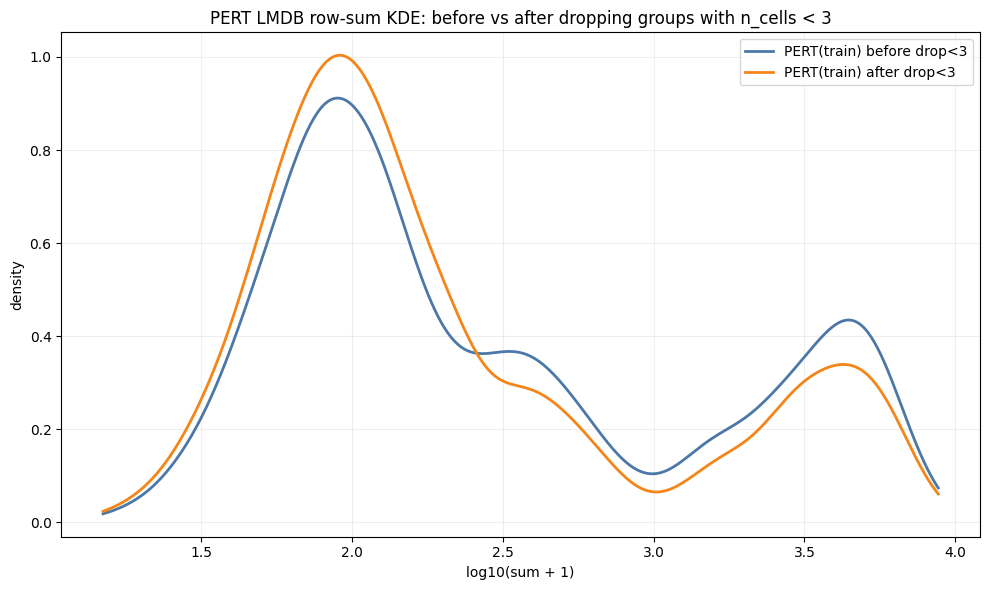

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/overlay_libsize_density_lmdb_pert_before_after.png


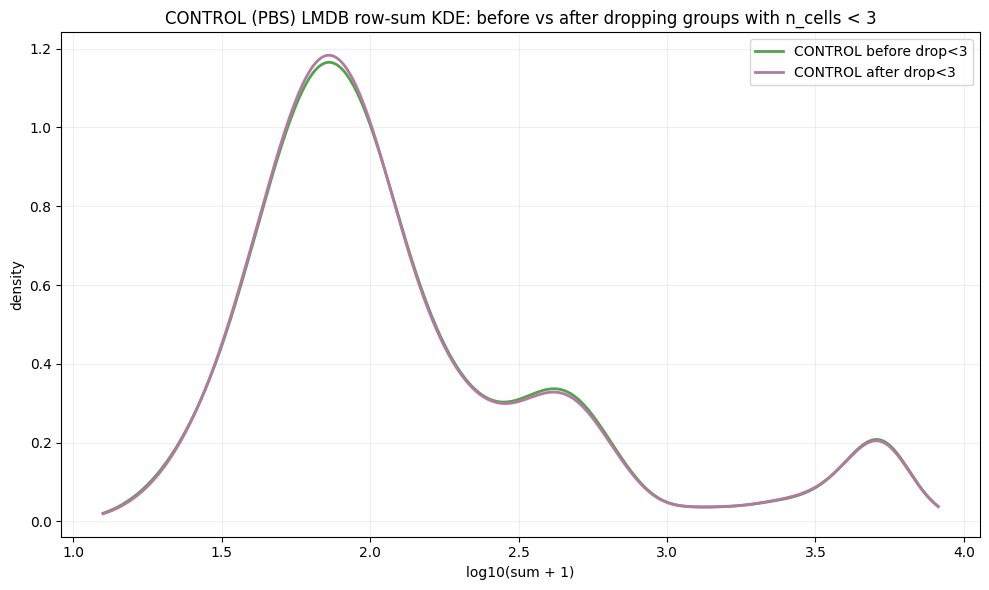

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/overlay_libsize_density_lmdb_control_before_after.png


In [2]:
# ===== LMDB libsize overlay: before vs after drop groups with n_cells < 3 =====
import os
import pickle
import lmdb
import numpy as np
import matplotlib.pyplot as plt

# Before filtering (<3 not dropped)
lmdb_train_before = "./pbmc_train_exclude_high_no_plasmablast_ilc"
lmdb_control_before = "./pbmc_control_exclude_high_no_plasmablast_ilc"

# After filtering (drop groups with n_cells < 3)
lmdb_train_after = "./pbmc_train_exclude_high_no_plasmablast_ilc_ge3"
lmdb_control_after = "./pbmc_control_exclude_high_no_plasmablast_ilc_ge3"

out_png = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/overlay_libsize_density_lmdb.png"
os.makedirs(os.path.dirname(out_png), exist_ok=True)


def sample_lmdb_row_sums(lmdb_path: str, n_groups: int = 200, seed: int = 0) -> np.ndarray:
    """Return per-cell row sums sampled from LMDB.

    Supports both formats used here:
    - pert/train/val/test LMDB: keys are "0..N-1" strings, and has __len__
    - control LMDB: keys are tuple strings, and has __len__ + __keys__

    NOTE: This "libsize" is sum of stored values (typically log1p normalized values).
    """
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    out = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)

        keys_buf = txn.get(b"__keys__")
        if keys_buf is not None:
            keys = pickle.loads(keys_buf)
            chosen = r.choice(len(keys), size=n_groups, replace=False)
            for j in chosen:
                k = keys[int(j)]
                buf = txn.get(str(k).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj
                if isinstance(obj, dict) and "cell_matrix" in obj:
                    X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())
        else:
            idxs = r.choice(n, size=n_groups, replace=False)
            for i in idxs:
                buf = txn.get(str(int(i)).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())

    env.close()
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


def pct_summary(x: np.ndarray, name: str):
    qs = [0, 1, 5, 10, 50, 90, 95, 99, 100]
    qv = np.percentile(x, qs)
    print(f"[{name}] n={x.size:,} min/p1/p5/p10/p50/p90/p95/p99/max = " + "/".join([f"{v:.3g}" for v in qv]))


# Sample LMDB row-sums
train_before = sample_lmdb_row_sums(lmdb_train_before, n_groups=200, seed=1)
control_before = sample_lmdb_row_sums(lmdb_control_before, n_groups=200, seed=2)
train_after = sample_lmdb_row_sums(lmdb_train_after, n_groups=200, seed=3)
control_after = sample_lmdb_row_sums(lmdb_control_after, n_groups=200, seed=4)

pct_summary(train_before, "pert(train)_before(no drop <3)")
pct_summary(train_after, "pert(train)_after(drop <3)")
pct_summary(control_before, "control_before(no drop <3)")
pct_summary(control_after, "control_after(drop <3)")

# Plot (smooth KDE curves) — split into 2 figures
from scipy.stats import gaussian_kde

bw_adjust = 1.5  # 越大越平滑（可按需调到 1.0~3.0）

def kde_on_log10(x: np.ndarray, grid: np.ndarray, bw_adjust: float = 1.5) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 10:
        return np.full_like(grid, np.nan, dtype=np.float64)
    z = np.log10(x + 1.0)
    kde = gaussian_kde(z, bw_method=lambda k: k.scotts_factor() * bw_adjust)
    return kde(grid)

def make_grid(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    all_x = np.concatenate([a, b]).astype(np.float64)
    all_x = all_x[np.isfinite(all_x)]
    lo = np.percentile(all_x, 0.1)
    hi = np.percentile(all_x, 99.9)
    lo = max(lo, 0.0)
    return np.linspace(np.log10(lo + 1.0), np.log10(hi + 1.0), 512)

out_dir = os.path.dirname(out_png)
pert_png = os.path.join(out_dir, "overlay_libsize_density_lmdb_pert_before_after.png")
control_png = os.path.join(out_dir, "overlay_libsize_density_lmdb_control_before_after.png")

# ---- Figure 1: PERT (use train LMDB as pert proxy) before vs after ----
pert_grid = make_grid(train_before, train_after)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(pert_grid, kde_on_log10(train_before, pert_grid, bw_adjust=bw_adjust), linewidth=2, label="PERT(train) before drop<3", color="#4C78A8")
ax.plot(pert_grid, kde_on_log10(train_after, pert_grid, bw_adjust=bw_adjust), linewidth=2, label="PERT(train) after drop<3", color="#F58518")
ax.set_title("PERT LMDB row-sum KDE: before vs after dropping groups with n_cells < 3")
ax.set_xlabel("log10(sum + 1)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(pert_png, dpi=200)
plt.show()
print("saved:", pert_png)

# ---- Figure 2: CONTROL (PBS) before vs after ----
control_grid = make_grid(control_before, control_after)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(control_grid, kde_on_log10(control_before, control_grid, bw_adjust=bw_adjust), linewidth=2, label="CONTROL before drop<3", color="#54A24B")
ax.plot(control_grid, kde_on_log10(control_after, control_grid, bw_adjust=bw_adjust), linewidth=2, label="CONTROL after drop<3", color="#B279A2")
ax.set_title("CONTROL (PBS) LMDB row-sum KDE: before vs after dropping groups with n_cells < 3")
ax.set_xlabel("log10(sum + 1)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(control_png, dpi=200)
plt.show()
print("saved:", control_png)


[exclude_high pert values (nonzero)] n=2,000,000 min/p1/p5/p10/p50/p90/p95/p99/max=0.693/0.693/0.693/0.693/1.61/14.7/15.4/16.6/20
[exclude_high control values (nonzero)] n=2,000,000 min/p1/p5/p10/p50/p90/p95/p99/max=0.693/0.693/0.693/0.693/1.1/14.2/15.2/16.5/19.8


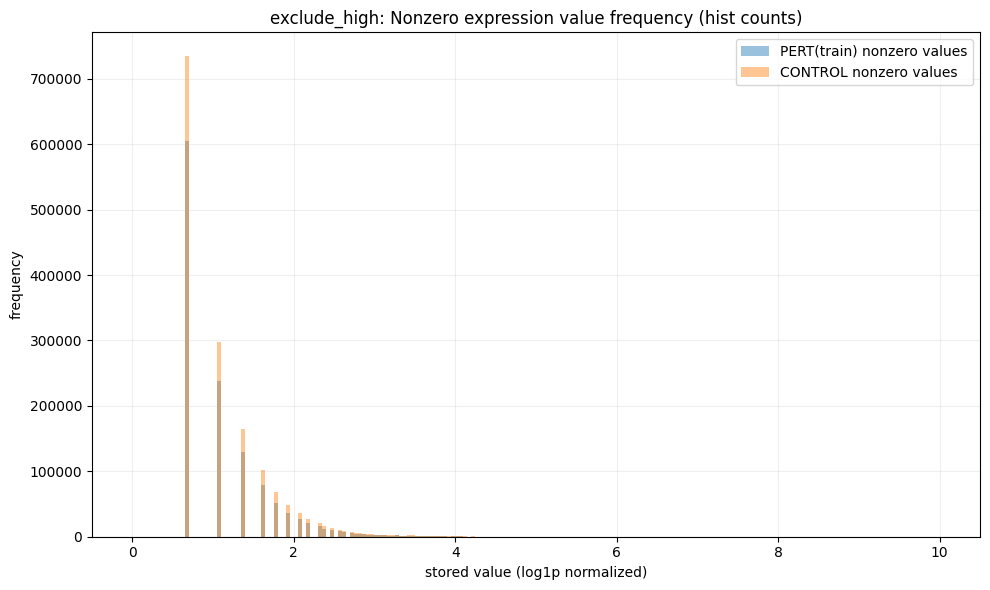

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_value_frequency_hist.png


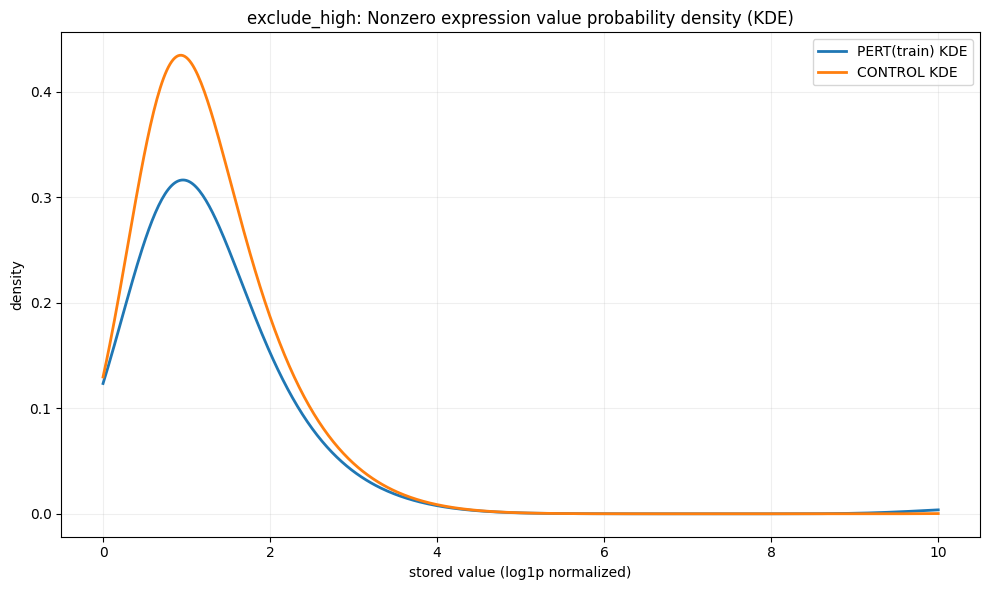

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_value_probability_kde.png


[exclude_high pert libsize(row-sum)] n=307,200 min/p1/p5/p10/p50/p90/p95/p99/max=6.24/21.6/35.4/46.3/133/3.85e+03/4.92e+03/6.58e+03/1.06e+04
[exclude_high control libsize(row-sum)] n=629,701 min/p1/p5/p10/p50/p90/p95/p99/max=4.16/17.7/27.5/35.4/88.7/641/3.86e+03/6.18e+03/1.06e+04


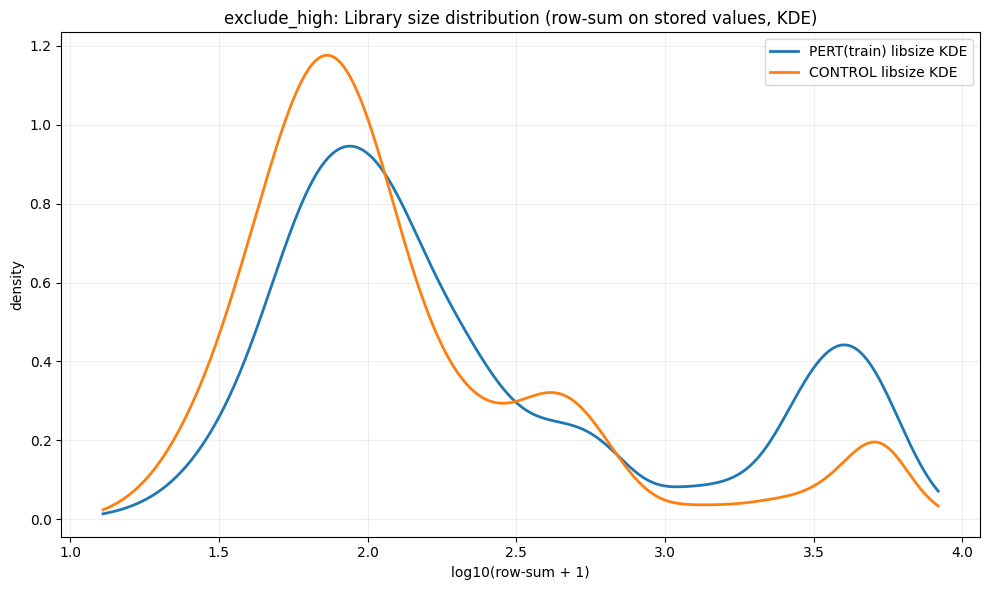

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_library_size_kde.png


In [3]:
# ===== exclude_high (no ge3) 频数/概率/Library size 分布图（LMDB抽样） =====
import os
import pickle
import lmdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# exclude_high (before drop<3)
pert_lmdb = "./pbmc_train_exclude_high_no_plasmablast_ilc"      # 用 train 代表 pert 分布
control_lmdb = "./pbmc_control_exclude_high_no_plasmablast_ilc"  # PBS control

# 输出目录：沿用你之前的 compare_outputs 目录
out_dir = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212"
os.makedirs(out_dir, exist_ok=True)

rng = np.random.default_rng(0)


def _sample_pert_values(lmdb_path: str, n_groups: int = 80, max_values: int = 2_000_000, seed: int = 0) -> np.ndarray:
    """Sample nonzero expression values from pert/train LMDB.

    Values are stored as sparse matrices in obj['cell_matrix'].
    """
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    vals = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        idxs = r.choice(n, size=n_groups, replace=False)
        for i in idxs:
            buf = txn.get(str(int(i)).encode("utf-8"))
            if buf is None:
                continue
            obj = pickle.loads(buf)
            X = obj["cell_matrix"]
            # X should be sparse
            if hasattr(X, "data"):
                vals.append(X.data)
            else:
                v = X[X > 0].ravel()
                vals.append(v)
    env.close()
    if not vals:
        return np.array([], dtype=np.float32)
    v = np.concatenate(vals).astype(np.float32)
    if v.size > max_values:
        v = v[r.choice(v.size, size=max_values, replace=False)]
    return v


def _sample_control_values(lmdb_path: str, n_keys: int = 200, max_values: int = 2_000_000, seed: int = 0) -> np.ndarray:
    """Sample nonzero expression values from control LMDB.

    Control LMDB stores matrix directly (CSR) keyed by cartesian_key strings.
    """
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    vals = []
    with env.begin(write=False) as txn:
        keys_buf = txn.get(b"__keys__")
        if keys_buf is None:
            return np.array([], dtype=np.float32)
        keys = pickle.loads(keys_buf)
        n_keys = min(n_keys, len(keys))
        chosen = r.choice(len(keys), size=n_keys, replace=False)
        for j in chosen:
            k = keys[int(j)]
            buf = txn.get(str(k).encode("utf-8"))
            if buf is None:
                continue
            X = pickle.loads(buf)
            if hasattr(X, "data"):
                vals.append(X.data)
            else:
                v = X[X > 0].ravel()
                vals.append(v)
    env.close()
    if not vals:
        return np.array([], dtype=np.float32)
    v = np.concatenate(vals).astype(np.float32)
    if v.size > max_values:
        v = v[r.choice(v.size, size=max_values, replace=False)]
    return v


def _sample_row_sums(lmdb_path: str, n_groups: int = 200, seed: int = 0) -> np.ndarray:
    """Sample per-cell row sums from LMDB (sum of stored values)."""
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    out = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        keys_buf = txn.get(b"__keys__")
        if keys_buf is not None:
            # control
            keys = pickle.loads(keys_buf)
            chosen = r.choice(len(keys), size=min(n_groups, len(keys)), replace=False)
            for j in chosen:
                k = keys[int(j)]
                buf = txn.get(str(k).encode("utf-8"))
                if buf is None:
                    continue
                X = pickle.loads(buf)
                out.append(np.asarray(X.sum(axis=1)).ravel())
        else:
            # pert
            idxs = r.choice(n, size=n_groups, replace=False)
            for i in idxs:
                buf = txn.get(str(int(i)).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())
    env.close()
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


def _kde_curve(x: np.ndarray, grid: np.ndarray, bw_adjust: float = 1.5) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 20:
        return np.full_like(grid, np.nan, dtype=np.float64)
    kde = gaussian_kde(x, bw_method=lambda k: k.scotts_factor() * bw_adjust)
    return kde(grid)


def _summary(x: np.ndarray, name: str):
    qs = [0, 1, 5, 10, 50, 90, 95, 99, 100]
    qv = np.percentile(x, qs)
    print(f"[{name}] n={x.size:,} min/p1/p5/p10/p50/p90/p95/p99/max=" + "/".join([f"{v:.3g}" for v in qv]))


# ---------- 1) 表达值频数分布（直方图，counts） ----------
pert_vals = _sample_pert_values(pert_lmdb, n_groups=80, max_values=2_000_000, seed=1)
control_vals = _sample_control_values(control_lmdb, n_keys=200, max_values=2_000_000, seed=2)

_summary(pert_vals, "exclude_high pert values (nonzero)")
_summary(control_vals, "exclude_high control values (nonzero)")

freq_png = os.path.join(out_dir, "exclude_high_value_frequency_hist.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# values are log1p normalized values; typical range ~[0, 10]
bins = np.linspace(0, 10, 201)
ax.hist(pert_vals, bins=bins, density=False, alpha=0.45, label="PERT(train) nonzero values")
ax.hist(control_vals, bins=bins, density=False, alpha=0.45, label="CONTROL nonzero values")
ax.set_title("exclude_high: Nonzero expression value frequency (hist counts)")
ax.set_xlabel("stored value (log1p normalized)")
ax.set_ylabel("frequency")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(freq_png, dpi=200)
plt.show()
print("saved:", freq_png)


# ---------- 2) 表达值概率分布（KDE，density） ----------
prob_png = os.path.join(out_dir, "exclude_high_value_probability_kde.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bw_adjust = 1.8  # 更平滑一些
lo = 0.0
hi = float(np.percentile(np.concatenate([pert_vals, control_vals]), 99.9))
hi = min(max(hi, 1.0), 10.0)
val_grid = np.linspace(lo, hi, 512)

ax.plot(val_grid, _kde_curve(pert_vals, val_grid, bw_adjust=bw_adjust), linewidth=2, label="PERT(train) KDE")
ax.plot(val_grid, _kde_curve(control_vals, val_grid, bw_adjust=bw_adjust), linewidth=2, label="CONTROL KDE")
ax.set_title("exclude_high: Nonzero expression value probability density (KDE)")
ax.set_xlabel("stored value (log1p normalized)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(prob_png, dpi=200)
plt.show()
print("saved:", prob_png)


# ---------- 3) Library size 分布（按行求和，KDE） ----------
pert_lib = _sample_row_sums(pert_lmdb, n_groups=300, seed=3)
control_lib = _sample_row_sums(control_lmdb, n_groups=300, seed=4)

_summary(pert_lib, "exclude_high pert libsize(row-sum)")
_summary(control_lib, "exclude_high control libsize(row-sum)")

lib_png = os.path.join(out_dir, "exclude_high_library_size_kde.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 用 log10(sum+1) 空间做 KDE 更稳定
z1 = np.log10(pert_lib + 1.0)
z2 = np.log10(control_lib + 1.0)
allz = np.concatenate([z1, z2])
grid = np.linspace(np.percentile(allz, 0.1), np.percentile(allz, 99.9), 512)

ax.plot(grid, _kde_curve(z1, grid, bw_adjust=1.6), linewidth=2, label="PERT(train) libsize KDE")
ax.plot(grid, _kde_curve(z2, grid, bw_adjust=1.6), linewidth=2, label="CONTROL libsize KDE")
ax.set_title("exclude_high: Library size distribution (row-sum on stored values, KDE)")
ax.set_xlabel("log10(row-sum + 1)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(lib_png, dpi=200)
plt.show()
print("saved:", lib_png)


In [4]:
# [('Donor5', 'Plasmablast', 'PBS')]
mask = (
    (pbmc_hvg.obs["donor"] == "Donor5") &
    (pbmc_hvg.obs["cell_type"] == "Plasmablast") 

)

In [5]:
matched_obs = pbmc_hvg.obs.loc[mask]
matched_obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type


In [ ]:
mask

89_103_005__s1      False
89_103_083__s1      False
89_103_085__s1      False
89_104_009__s1      False
89_104_025__s1      False
                    ...  
61_186_093__s144    False
61_186_108__s144    False
61_186_135__s144    False
61_186_157__s144    False
61_186_168__s144    False
Length: 9697884, dtype: bool

In [7]:
~mask

89_103_005__s1      True
89_103_083__s1      True
89_103_085__s1      True
89_104_009__s1      True
89_104_025__s1      True
                    ... 
61_186_093__s144    True
61_186_108__s144    True
61_186_135__s144    True
61_186_157__s144    True
61_186_168__s144    True
Length: 9697884, dtype: bool

[exclude_high_ge3 pert values (nonzero)] n=2,000,000 min/p1/p5/p10/p50/p90/p95/p99/max=0.693/0.693/0.693/0.693/2.48/14.9/15.6/16.7/20
[exclude_high_ge3 control values (nonzero)] n=2,000,000 min/p1/p5/p10/p50/p90/p95/p99/max=0.693/0.693/0.693/0.693/1.1/14.2/15.2/16.5/19.9


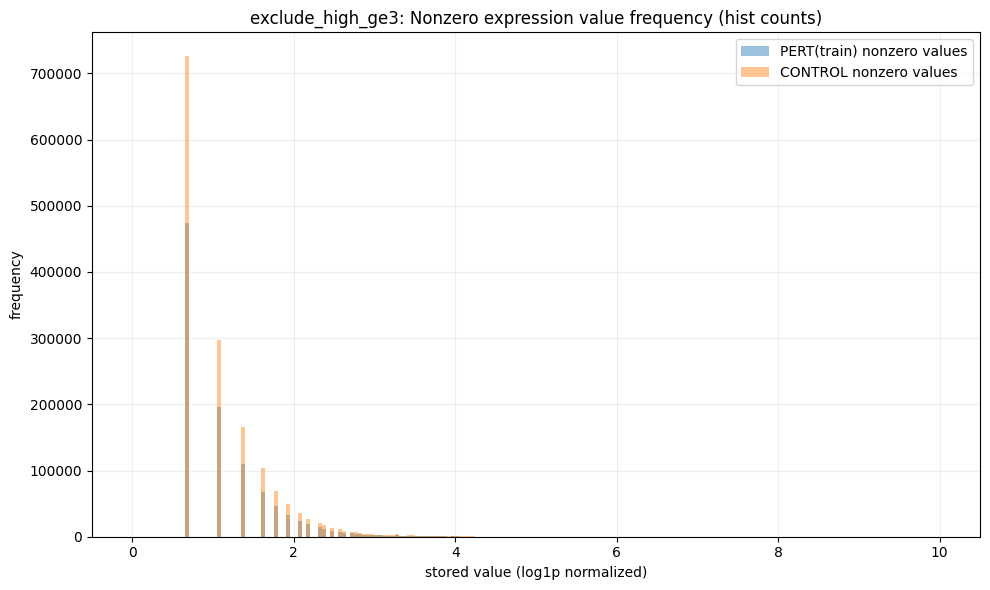

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_ge3_value_frequency_hist.png


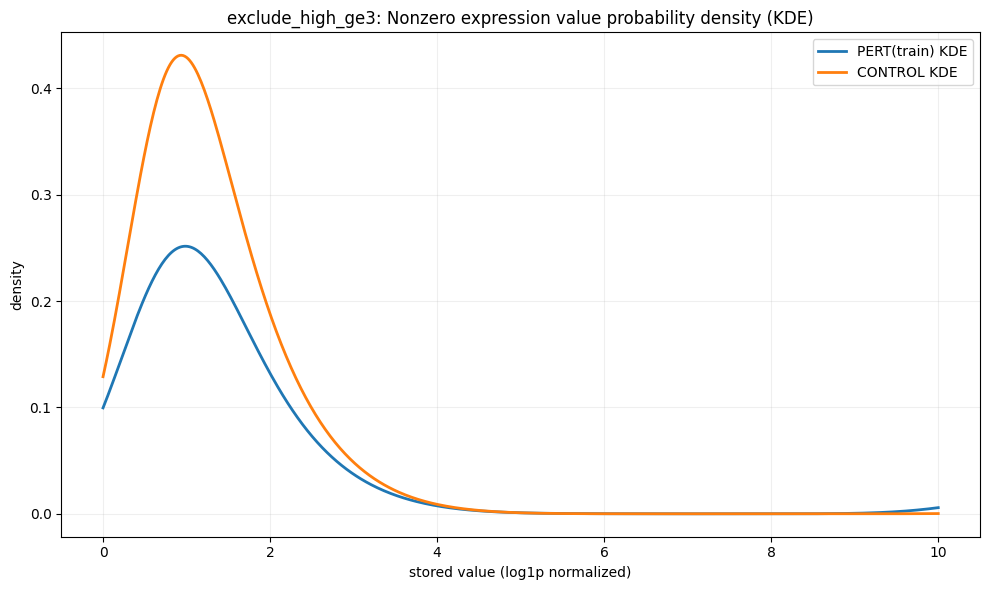

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_ge3_value_probability_kde.png


[exclude_high_ge3 pert libsize(row-sum)] n=307,200 min/p1/p5/p10/p50/p90/p95/p99/max=6.24/22.1/36.9/47.7/122/3.65e+03/4.84e+03/6.59e+03/1.01e+04
[exclude_high_ge3 control libsize(row-sum)] n=629,701 min/p1/p5/p10/p50/p90/p95/p99/max=4.16/17.7/27.5/35.4/88.7/641/3.86e+03/6.18e+03/1.06e+04


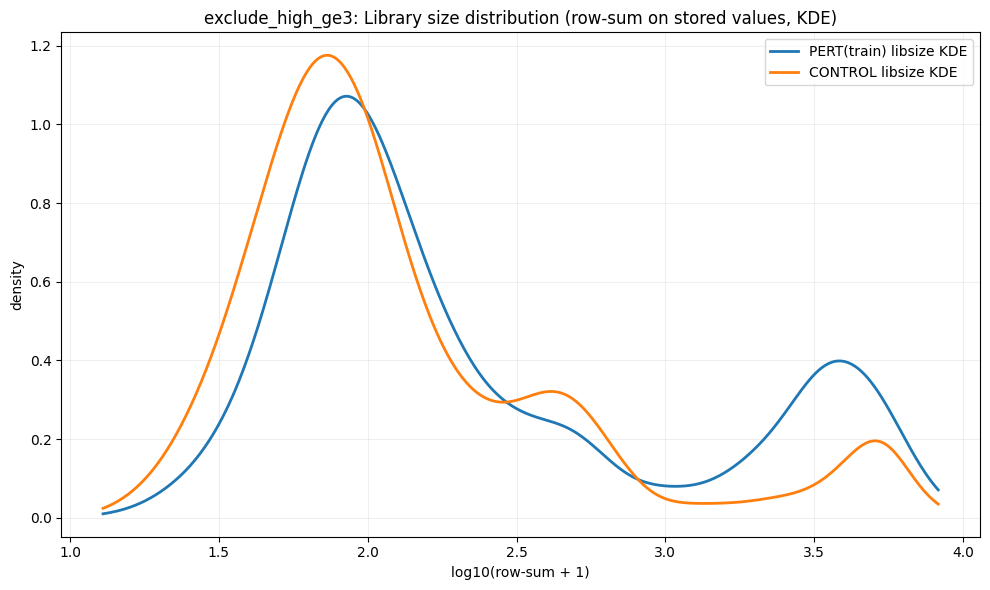

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/exclude_high_ge3_library_size_kde.png


In [8]:
# ===== exclude_high_ge3 (drop n_cells<3) 频数/概率/Library size 分布图（LMDB抽样） =====
import os
import pickle
import lmdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# exclude_high_ge3 (after drop<3)
pert_lmdb = "./pbmc_train_exclude_high_no_plasmablast_ilc_ge3"        # 用 train 代表 pert 分布
control_lmdb = "./pbmc_control_exclude_high_no_plasmablast_ilc_ge3"  # PBS control

out_dir = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212"
os.makedirs(out_dir, exist_ok=True)


def _sample_pert_values(lmdb_path: str, n_groups: int = 80, max_values: int = 2_000_000, seed: int = 0) -> np.ndarray:
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    vals = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        idxs = r.choice(n, size=n_groups, replace=False)
        for i in idxs:
            buf = txn.get(str(int(i)).encode("utf-8"))
            if buf is None:
                continue
            obj = pickle.loads(buf)
            X = obj["cell_matrix"]
            if hasattr(X, "data"):
                vals.append(X.data)
            else:
                vals.append(X[X > 0].ravel())
    env.close()
    if not vals:
        return np.array([], dtype=np.float32)
    v = np.concatenate(vals).astype(np.float32)
    if v.size > max_values:
        v = v[r.choice(v.size, size=max_values, replace=False)]
    return v


def _sample_control_values(lmdb_path: str, n_keys: int = 200, max_values: int = 2_000_000, seed: int = 0) -> np.ndarray:
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    vals = []
    with env.begin(write=False) as txn:
        keys_buf = txn.get(b"__keys__")
        if keys_buf is None:
            return np.array([], dtype=np.float32)
        keys = pickle.loads(keys_buf)
        n_keys = min(n_keys, len(keys))
        chosen = r.choice(len(keys), size=n_keys, replace=False)
        for j in chosen:
            k = keys[int(j)]
            buf = txn.get(str(k).encode("utf-8"))
            if buf is None:
                continue
            X = pickle.loads(buf)
            if hasattr(X, "data"):
                vals.append(X.data)
            else:
                vals.append(X[X > 0].ravel())
    env.close()
    if not vals:
        return np.array([], dtype=np.float32)
    v = np.concatenate(vals).astype(np.float32)
    if v.size > max_values:
        v = v[r.choice(v.size, size=max_values, replace=False)]
    return v


def _sample_row_sums(lmdb_path: str, n_groups: int = 200, seed: int = 0) -> np.ndarray:
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    out = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        keys_buf = txn.get(b"__keys__")
        if keys_buf is not None:
            keys = pickle.loads(keys_buf)
            chosen = r.choice(len(keys), size=min(n_groups, len(keys)), replace=False)
            for j in chosen:
                k = keys[int(j)]
                buf = txn.get(str(k).encode("utf-8"))
                if buf is None:
                    continue
                X = pickle.loads(buf)
                out.append(np.asarray(X.sum(axis=1)).ravel())
        else:
            idxs = r.choice(n, size=n_groups, replace=False)
            for i in idxs:
                buf = txn.get(str(int(i)).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())
    env.close()
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


def _kde_curve(x: np.ndarray, grid: np.ndarray, bw_adjust: float = 1.5) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < 20:
        return np.full_like(grid, np.nan, dtype=np.float64)
    kde = gaussian_kde(x, bw_method=lambda k: k.scotts_factor() * bw_adjust)
    return kde(grid)


def _summary(x: np.ndarray, name: str):
    qs = [0, 1, 5, 10, 50, 90, 95, 99, 100]
    qv = np.percentile(x, qs)
    print(f"[{name}] n={x.size:,} min/p1/p5/p10/p50/p90/p95/p99/max=" + "/".join([f"{v:.3g}" for v in qv]))


# 1) 表达值频数分布
pert_vals = _sample_pert_values(pert_lmdb, n_groups=80, max_values=2_000_000, seed=11)
control_vals = _sample_control_values(control_lmdb, n_keys=200, max_values=2_000_000, seed=12)

_summary(pert_vals, "exclude_high_ge3 pert values (nonzero)")
_summary(control_vals, "exclude_high_ge3 control values (nonzero)")

freq_png = os.path.join(out_dir, "exclude_high_ge3_value_frequency_hist.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bins = np.linspace(0, 10, 201)
ax.hist(pert_vals, bins=bins, density=False, alpha=0.45, label="PERT(train) nonzero values")
ax.hist(control_vals, bins=bins, density=False, alpha=0.45, label="CONTROL nonzero values")
ax.set_title("exclude_high_ge3: Nonzero expression value frequency (hist counts)")
ax.set_xlabel("stored value (log1p normalized)")
ax.set_ylabel("frequency")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(freq_png, dpi=200)
plt.show()
print("saved:", freq_png)


# 2) 表达值概率分布（KDE）
prob_png = os.path.join(out_dir, "exclude_high_ge3_value_probability_kde.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bw_adjust = 1.8
hi = float(np.percentile(np.concatenate([pert_vals, control_vals]), 99.9))
hi = min(max(hi, 1.0), 10.0)
val_grid = np.linspace(0.0, hi, 512)

ax.plot(val_grid, _kde_curve(pert_vals, val_grid, bw_adjust=bw_adjust), linewidth=2, label="PERT(train) KDE")
ax.plot(val_grid, _kde_curve(control_vals, val_grid, bw_adjust=bw_adjust), linewidth=2, label="CONTROL KDE")
ax.set_title("exclude_high_ge3: Nonzero expression value probability density (KDE)")
ax.set_xlabel("stored value (log1p normalized)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(prob_png, dpi=200)
plt.show()
print("saved:", prob_png)


# 3) Library size 分布（row-sum KDE）
pert_lib = _sample_row_sums(pert_lmdb, n_groups=300, seed=13)
control_lib = _sample_row_sums(control_lmdb, n_groups=300, seed=14)

_summary(pert_lib, "exclude_high_ge3 pert libsize(row-sum)")
_summary(control_lib, "exclude_high_ge3 control libsize(row-sum)")

lib_png = os.path.join(out_dir, "exclude_high_ge3_library_size_kde.png")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

z1 = np.log10(pert_lib + 1.0)
z2 = np.log10(control_lib + 1.0)
allz = np.concatenate([z1, z2])
grid = np.linspace(np.percentile(allz, 0.1), np.percentile(allz, 99.9), 512)

ax.plot(grid, _kde_curve(z1, grid, bw_adjust=1.6), linewidth=2, label="PERT(train) libsize KDE")
ax.plot(grid, _kde_curve(z2, grid, bw_adjust=1.6), linewidth=2, label="CONTROL libsize KDE")
ax.set_title("exclude_high_ge3: Library size distribution (row-sum on stored values, KDE)")
ax.set_xlabel("log10(row-sum + 1)")
ax.set_ylabel("density")
ax.legend(loc="best")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(lib_png, dpi=200)
plt.show()
print("saved:", lib_png)


lib_before n_cells: 824906
lib_after  n_cells: 820676


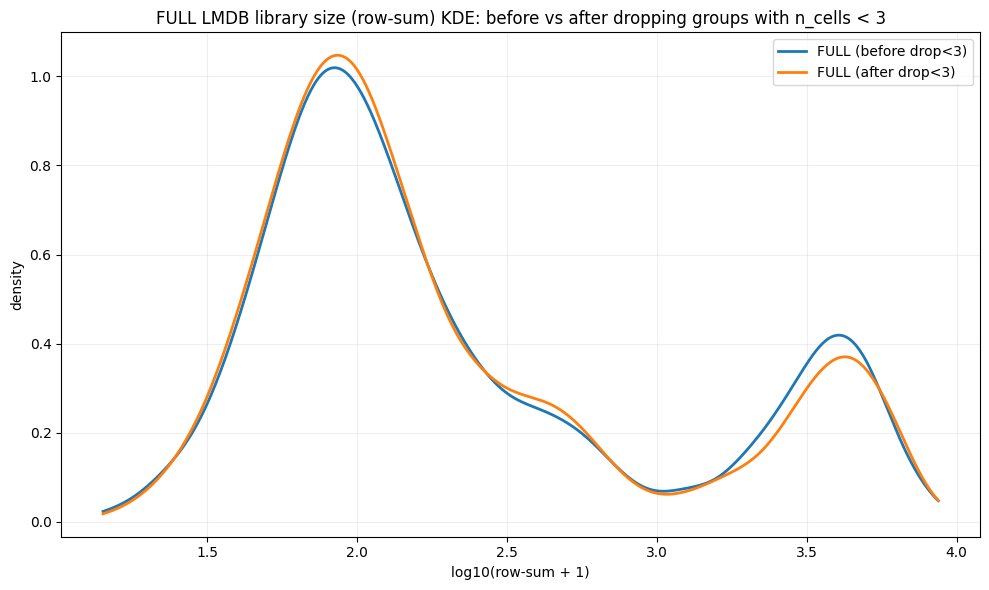

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/overlay_full_libsize_before_after.png


In [9]:
# ===== FULL dataset LMDB library size: before vs after dropping groups with n_cells < 3 =====
import os
import pickle
import lmdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

out_dir = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212"
os.makedirs(out_dir, exist_ok=True)

# before drop<3 (exclude_high)
lmdb_before = [
    "./pbmc_train_exclude_high_no_plasmablast_ilc",
    "./pbmc_val_exclude_high_no_plasmablast_ilc",
    "./pbmc_test_exclude_high_no_plasmablast_ilc",
    "./pbmc_control_exclude_high_no_plasmablast_ilc",
]

# after drop<3 (exclude_high_ge3)
lmdb_after = [
    "./pbmc_train_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_val_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_test_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_control_exclude_high_no_plasmablast_ilc_ge3",
]

out_png = os.path.join(out_dir, "overlay_full_libsize_before_after.png")


def sample_lmdb_row_sums_any(lmdb_path: str, n_groups: int, seed: int) -> np.ndarray:
    """Sample per-cell row sums from either pert LMDB or control LMDB."""
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    out = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        keys_buf = txn.get(b"__keys__")
        if keys_buf is not None:
            # control LMDB: sample keys
            keys = pickle.loads(keys_buf)
            n_groups = min(n_groups, len(keys))
            chosen = r.choice(len(keys), size=n_groups, replace=False)
            for j in chosen:
                k = keys[int(j)]
                buf = txn.get(str(k).encode("utf-8"))
                if buf is None:
                    continue
                X = pickle.loads(buf)
                out.append(np.asarray(X.sum(axis=1)).ravel())
        else:
            # pert LMDB: sample numeric indices
            idxs = r.choice(n, size=n_groups, replace=False)
            for i in idxs:
                buf = txn.get(str(int(i)).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())
    env.close()
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


def get_lmdb_len(lmdb_path: str) -> int:
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
    env.close()
    return n


def sample_full_libsize(lmdb_paths: list[str], total_groups: int = 800, seed: int = 0) -> np.ndarray:
    """Sample from multiple LMDBs proportional to their __len__."""
    lens = np.array([get_lmdb_len(p) for p in lmdb_paths], dtype=np.int64)
    probs = lens / lens.sum()

    # allocate number of groups per LMDB
    alloc = np.floor(probs * total_groups).astype(int)
    # distribute remainder
    rem = total_groups - alloc.sum()
    if rem > 0:
        extra = np.argsort(-probs)[:rem]
        alloc[extra] += 1

    out = []
    for i, (p, ng) in enumerate(zip(lmdb_paths, alloc)):
        if ng <= 0:
            continue
        out.append(sample_lmdb_row_sums_any(p, n_groups=int(ng), seed=seed + 100 * i))
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


# sample full dataset row-sums
lib_before = sample_full_libsize(lmdb_before, total_groups=800, seed=1)
lib_after = sample_full_libsize(lmdb_after, total_groups=800, seed=2)

print('lib_before n_cells:', lib_before.size)
print('lib_after  n_cells:', lib_after.size)

# KDE on log10(sum+1)
z_before = np.log10(lib_before + 1.0)
z_after = np.log10(lib_after + 1.0)

allz = np.concatenate([z_before, z_after])
lo = np.percentile(allz, 0.1)
hi = np.percentile(allz, 99.9)
xs = np.linspace(lo, hi, 512)

bw_adjust = 1.6
kde_before = gaussian_kde(z_before, bw_method=lambda k: k.scotts_factor() * bw_adjust)
kde_after = gaussian_kde(z_after, bw_method=lambda k: k.scotts_factor() * bw_adjust)

y_before = kde_before(xs)
y_after = kde_after(xs)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(xs, y_before, linewidth=2, label='FULL (before drop<3)')
ax.plot(xs, y_after, linewidth=2, label='FULL (after drop<3)')
ax.set_title('FULL LMDB library size (row-sum) KDE: before vs after dropping groups with n_cells < 3')
ax.set_xlabel('log10(row-sum + 1)')
ax.set_ylabel('density')
ax.legend(loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print('saved:', out_png)


sum_before n_cells: 1235941
sum_after  n_cells: 1237049


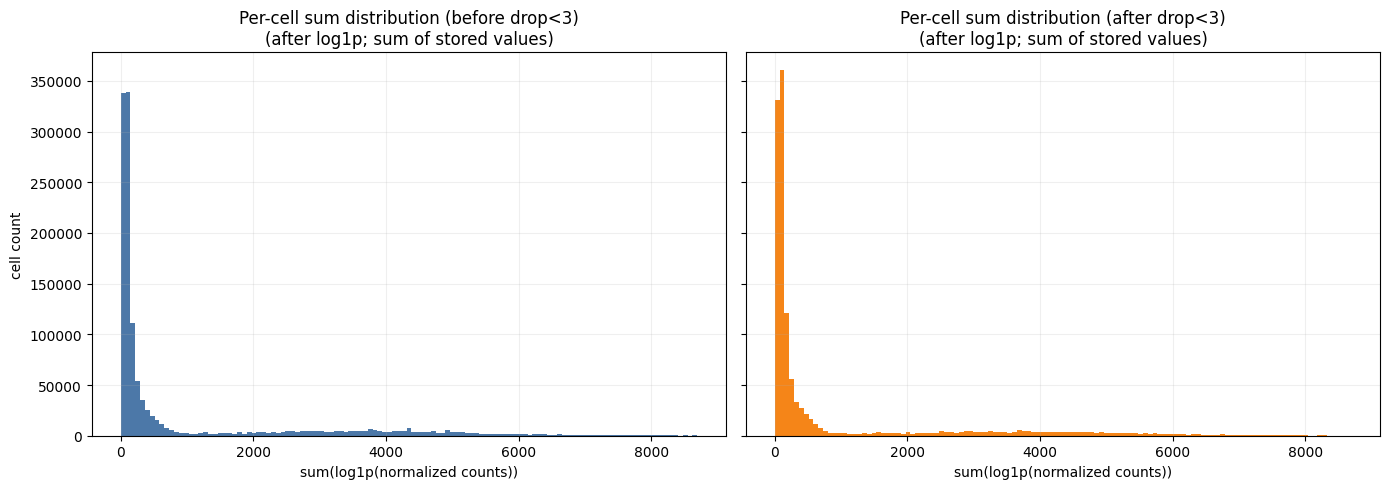

saved: /mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212/per_cell_sum_distribution_before_after_drop_lt3.png


In [10]:
# ===== Per-cell sum distribution (after log1p) — before vs after drop<3 (FULL LMDB) =====
import os
import pickle
import lmdb
import numpy as np
import matplotlib.pyplot as plt

out_dir = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212"
os.makedirs(out_dir, exist_ok=True)

# before drop<3 (exclude_high)
lmdb_before = [
    "./pbmc_train_exclude_high_no_plasmablast_ilc",
    "./pbmc_val_exclude_high_no_plasmablast_ilc",
    "./pbmc_test_exclude_high_no_plasmablast_ilc",
    "./pbmc_control_exclude_high_no_plasmablast_ilc",
]

# after drop<3 (exclude_high_ge3)
lmdb_after = [
    "./pbmc_train_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_val_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_test_exclude_high_no_plasmablast_ilc_ge3",
    "./pbmc_control_exclude_high_no_plasmablast_ilc_ge3",
]

out_png = os.path.join(out_dir, "per_cell_sum_distribution_before_after_drop_lt3.png")


def get_lmdb_len(lmdb_path: str) -> int:
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
    env.close()
    return n


def sample_lmdb_row_sums_any(lmdb_path: str, n_groups: int, seed: int) -> np.ndarray:
    """Sample per-cell row sums from either pert LMDB or control LMDB."""
    r = np.random.default_rng(seed)
    env = lmdb.open(lmdb_path, readonly=True, lock=False, readahead=False, max_dbs=1)
    out = []
    with env.begin(write=False) as txn:
        n = int(txn.get(b"__len__"))
        n_groups = min(n_groups, n)
        keys_buf = txn.get(b"__keys__")
        if keys_buf is not None:
            # control LMDB: sample keys
            keys = pickle.loads(keys_buf)
            n_groups = min(n_groups, len(keys))
            chosen = r.choice(len(keys), size=n_groups, replace=False)
            for j in chosen:
                k = keys[int(j)]
                buf = txn.get(str(k).encode("utf-8"))
                if buf is None:
                    continue
                X = pickle.loads(buf)
                out.append(np.asarray(X.sum(axis=1)).ravel())
        else:
            # pert LMDB: sample numeric indices
            idxs = r.choice(n, size=n_groups, replace=False)
            for i in idxs:
                buf = txn.get(str(int(i)).encode("utf-8"))
                if buf is None:
                    continue
                obj = pickle.loads(buf)
                X = obj["cell_matrix"]
                out.append(np.asarray(X.sum(axis=1)).ravel())
    env.close()
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


def sample_full_row_sums(lmdb_paths: list[str], total_groups: int = 1200, seed: int = 0) -> np.ndarray:
    """Sample from multiple LMDBs proportional to their __len__."""
    lens = np.array([get_lmdb_len(p) for p in lmdb_paths], dtype=np.int64)
    probs = lens / lens.sum()

    alloc = np.floor(probs * total_groups).astype(int)
    rem = total_groups - alloc.sum()
    if rem > 0:
        extra = np.argsort(-probs)[:rem]
        alloc[extra] += 1

    out = []
    for i, (p, ng) in enumerate(zip(lmdb_paths, alloc)):
        if ng <= 0:
            continue
        out.append(sample_lmdb_row_sums_any(p, n_groups=int(ng), seed=seed + 100 * i))
    if not out:
        return np.array([], dtype=np.float32)
    return np.concatenate(out).astype(np.float32)


# sample per-cell sums (these are sums of stored log1p values)
sum_before = sample_full_row_sums(lmdb_before, total_groups=1200, seed=1)
sum_after = sample_full_row_sums(lmdb_after, total_groups=1200, seed=2)

print("sum_before n_cells:", sum_before.size)
print("sum_after  n_cells:", sum_after.size)

# Use shared bin edges for a fair comparison
# clip x-range by 99.9% quantile to avoid huge tails dominating visualization
hi = float(np.percentile(np.concatenate([sum_before, sum_after]), 99.9))
hi = max(hi, 1.0)

bins = np.linspace(0.0, hi, 120)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].hist(sum_before, bins=bins, color="#4C78A8")
axes[0].set_title("Per-cell sum distribution (before drop<3)\n(after log1p; sum of stored values)")
axes[0].set_xlabel("sum(log1p(normalized counts))")
axes[0].set_ylabel("cell count")

axes[1].hist(sum_after, bins=bins, color="#F58518")
axes[1].set_title("Per-cell sum distribution (after drop<3)\n(after log1p; sum of stored values)")
axes[1].set_xlabel("sum(log1p(normalized counts))")

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print("saved:", out_png)


In [ ]:
# ===== Control vs Pert (0/3/10/20) + metrics on panel =====
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, wasserstein_distance, ks_2samp
from scipy.spatial.distance import jensenshannon

h5ad_path = "./only_hvg/PBMC_only_hvg_norm_exclude_high_no_plasmablast_ilc.h5ad"
out_dir = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/remote-chen/nemo_cellflow/preprocessing/compare_outputs/tahoe_vs_pbmc_exclhigh_ge3_lmdb_20260212"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "control_vs_pert_libsize_thresholds_0_3_10_20_metrics.png")

adata = ad.read_h5ad(h5ad_path, backed="r")
obs = adata.obs[["donor", "cell_type", "cytokine"]].copy()
gk = obs["donor"].astype(str) + "||" + obs["cell_type"].astype(str) + "||" + obs["cytokine"].astype(str)
obs["group_size"] = gk.map(gk.value_counts()).astype(np.int32)

def sample_rowsums(idxs, seed, max_cells=200000, chunk=20000):
    r = np.random.default_rng(seed)
    idxs = np.asarray(idxs, dtype=np.int64)
    if idxs.size == 0:
        return np.array([], dtype=np.float32)
    if idxs.size > max_cells:
        idxs = r.choice(idxs, size=max_cells, replace=False)
    out = []
    for s in range(0, idxs.size, chunk):
        X = adata.X[idxs[s:s+chunk]]
        out.append(np.asarray(X.sum(axis=1)).ravel())
    return np.concatenate(out).astype(np.float32)

def kde(z, x):
    z = z[np.isfinite(z)]
    if z.size < 20:
        return np.full_like(x, np.nan)
    k = gaussian_kde(z, bw_method=lambda kk: kk.scotts_factor() * 1.6)
    return k(x)

def jsd(z1, z2, bins=120):
    lo, hi = np.percentile(np.concatenate([z1, z2]), [0.1, 99.9])
    e = np.linspace(lo, hi, bins + 1)
    p, _ = np.histogram(z1, bins=e)
    q, _ = np.histogram(z2, bins=e)
    p = p.astype(float); q = q.astype(float)
    p = p / p.sum() if p.sum() > 0 else np.ones_like(p) / len(p)
    q = q / q.sum() if q.sum() > 0 else np.ones_like(q) / len(q)
    return float(jensenshannon(p, q, base=2.0))

ths = [0, 3, 10, 20]
res = {}
for t in ths:
    keep = obs["group_size"].values >= t
    c_idx = np.where(keep & (obs["cytokine"].values == "PBS"))[0]
    p_idx = np.where(keep & (obs["cytokine"].values != "PBS"))[0]
    c = sample_rowsums(c_idx, 100 + t)
    p = sample_rowsums(p_idx, 200 + t)
    res[t] = (c, p)
adata.file.close()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()
for i, t in enumerate(ths):
    ax = axes[i]
    c, p = res[t]
    zc = np.log10(c + 1.0)
    zp = np.log10(p + 1.0)
    lo, hi = np.percentile(np.concatenate([zc, zp]), [0.1, 99.9])
    x = np.linspace(lo, hi, 512)
    ax.plot(x, kde(zc, x), lw=2, label="control", color="#4C78A8")
    ax.plot(x, kde(zp, x), lw=2, label="pert", color="#F58518")
    w = wasserstein_distance(zc, zp)
    d = ks_2samp(zc, zp).statistic
    j = jsd(zc, zp)
    ax.text(0.98, 0.98, f"Wass={w:.4f}\nJSD={j:.4f}\nKS={d:.4f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
    ax.set_title(f"group size >= {t}")
    ax.grid(True, alpha=0.2)
    if i in (2, 3):
        ax.set_xlabel("log10(sum(log1p values)+1)")
    if i in (0, 2):
        ax.set_ylabel("density")

h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Control vs Pert with Wasserstein / JSD / KS", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(out_png, dpi=200)
plt.show()
print("saved:", out_png)
